# Neighborhood-Based Fairness Audit Robustness: A Geometric Perspective

이 노트북은 `implementation.py`에 구현된 '근처 기반 공정성 감사(neighborhood-based fairness audit)'의 견고함(robustness)을 분석합니다.
주요 개념인 **Audit Score**(이웃 간 예측값 일관성)와 **Audit Volatility**(섭동 시 감사 결과의 변동성)을 시각화하여,
데이터 공간의 작은 변화(노이즈/섭동)가 공정성 평가에 미치는 영향을 탐구합니다.

**실험 설정:**
1. 합성 데이터 생성 (2차원 가우시안 분포 기반)
2. 다양한 $k$-값(이웃 수)과 $\epsilon$-값(섭동 크기) 조합으로 감사 수행
3. Audit Volatility와 Neighborhood Invariance(이웃 집합 유지율)를 계산 및 시각화

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import logging

# 로깅 레벨을 INFO로 설정하여 실행 중 불필요한 디버그 메시지는 줄이고, 주요 단계만 출력
logging.getLogger().setLevel(logging.INFO)

# 구현 코드 import
from implementation import (
    generate_synthetic_data,
    calculate_audit_score,
    DEFAULT_N_SAMPLES,
    DEFAULT_DIM,
    DEFAULT_K_NEIGHBORS,
    DEFAULT_EPSILON_STEPS,
    DEFAULT_TRIALS,
    RANDOM_SEED
)

# 추가 유틸리티: 이웃 불변성(Jaccard Similarity) 계산 함수
# implementation.py에 명시적인 함수가 없으므로, 이 데모에서 직접 계산하기 위함.
def calculate_jaccard_similarity(neighbors_orig: np.ndarray, neighbors_perturbed: np.ndarray) -> float:
    """
    원래 이웃 집합과 섭동 후 이웃 집합의 자카드 유사도(Jaccard Similarity)를 계산.
    
    Args:
        neighbors_orig: 원래 이웃들의 인덱스 배열 (1D)
        neighbors_perturbed: 섭동 후 이웃들의 인덱스 배열 (1D)
        
    Returns:
        float: 자카드 유사도 (0.0 ~ 1.0)
    """
    if len(neighbors_orig) == 0 or len(neighbors_perturbed) == 0:
        return 0.0
    intersection = len(np.intersect1d(neighbors_orig, neighbors_perturbed))
    union = len(np.union1d(neighbors_orig, neighbors_perturbed))
    if union == 0:
        return 1.0
    return intersection / union

# 이웃 집합 추출 함수 (k-NN 인덱스 반환)
def get_k_neighbors_indices(X: np.ndarray, idx: int, k: int) -> np.ndarray:
    """
    특정 포인트의 k-최근접 이웃 인덱스를 반환 (자기 자신을 제외).
    """
    distances = np.sum((X - X[idx]) ** 2, axis=1)
    # 자기 자신 제외 (거리 0인 값)
    distances[idx] = np.inf
    # k개 가장 작은 값의 인덱스
    neighbor_indices = np.argpartition(distances, k)[:k]
    return neighbor_indices

# 1. 데이터 생성 및 초기 감사 점수 확인

`generate_synthetic_data`를 사용해 2차원 특징 공간에서 1000개의 데이터 포인트와 그에 대한 모델 예측값을 생성합니다.
초기 상태(섭동 $\epsilon=0$)에서의 Audit Score를 확인합니다.

2026-08-27 09:59:42,883 - INFO - implementation - Generating synthetic data: 500 samples in 2D space. Seed=42


2026-08-27 09:59:42,897 - DEBUG - implementation - X range: [-3.24, 3.85]


2026-08-27 09:59:42,897 - DEBUG - implementation - y_pred range: [-3.02, 4.46]


2026-08-27 09:59:42,898 - INFO - implementation - Calculating Audit Score. k=5, n_samples=500


2026-08-27 09:59:42,903 - DEBUG - implementation - Processed sample 0/500, current avg score: 0.1099


...

2026-08-27 09:59:44,132 - DEBUG - matplotlib.font_manager - findfont: score(FontEntry(fname='/System/Library/Fonts/Supplemental/Myanmar MN.ttc', index=1, name='Myanmar MN', style='normal', variant='normal', weight=400, stretch='normal', size='scalable')) = 10.05


2026-08-27 09:59:44,132 - DEBUG - matplotlib.font_manager - findfont: score(FontEntry(fname='/System/Library/Fonts/Supplemental/Arial Bold Italic.ttf', index=0, name='Arial', style='italic', variant='normal', weight=700, stretch='normal', size='scalable')) = 7.698636363636363


2026-08-27 09:59:44,133 - DEBUG - matplotlib.font_manager - findfont: score(FontEntry(fname='/System/Library/AssetsV2/com_apple_MobileAsset_Font8/70875a1270987c17cfd6f40cd3d755ec04d03b33.asset/AssetData/Baoli.ttc', index=0, name='Baoli SC', style='normal', variant='normal', weight=400, stretch='normal', size='scalable')) = 10.05


2026-08-27 09:59:44,133 - DEBUG - matplotlib.font_manager - findfont: score(FontEntry(fname='/System/Library/AssetsV2/com_apple_MobileAsset_Font8/70875a1270987c17cfd6f40cd3d755ec04d03b33.asset/AssetData/Baoli.ttc', index=1, name='Baoli TC', style='normal', variant='normal', weight=400, stretch='normal', size='scalable')) = 10.05


2026-08-27 09:59:44,133 - DEBUG - matplotlib.font_manager - findfont: Matching sans\-serif:style=normal:variant=normal:weight=normal:stretch=normal:size=12.0 to DejaVu Sans ('/Volumes/ssd1/content-engine/repos/paper-reviews/papers/2608.24818-a-geometric-theory-of-robust-fairness-au/.venv/lib/python3.11/site-packages/matplotlib/mpl-data/fonts/ttf/DejaVuSans.ttf') with score of 0.050000.


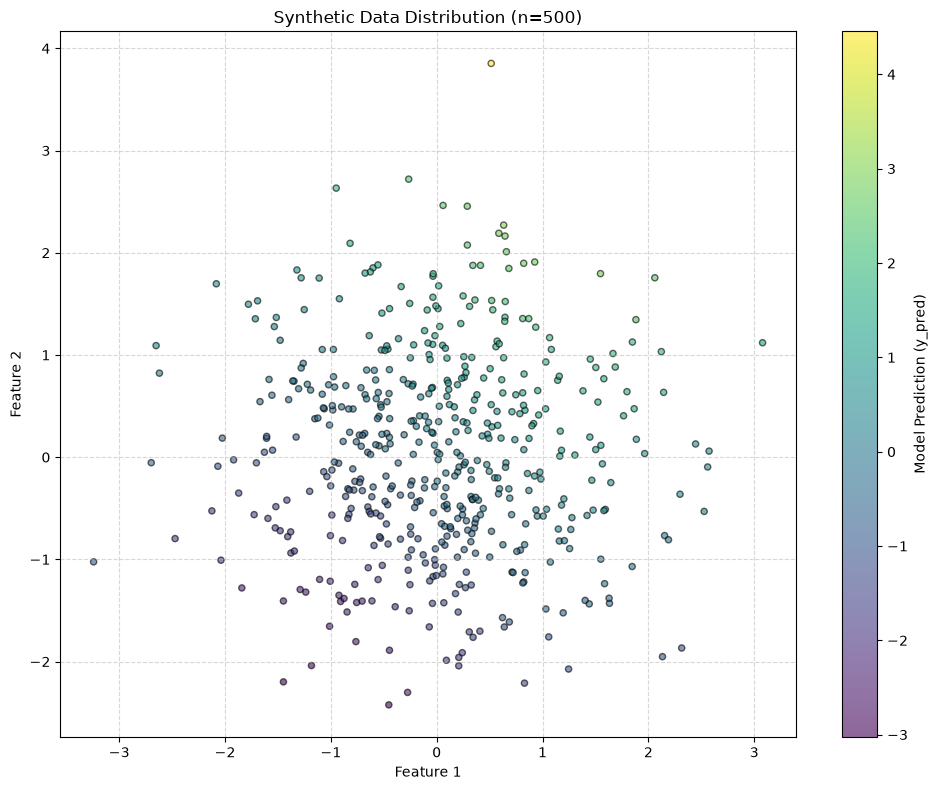

In [2]:
# 데이터 생성
n_samples = 500  # 계산 시간 절감을 위해 샘플 수 감소 (원래 1000)
dim = 2
seed = RANDOM_SEED

X, y_pred = generate_synthetic_data(n_samples=n_samples, dim=dim, seed=seed)
print(f"데이터 생성 완료: {X.shape}, y_pred range: [{y_pred.min():.2f}, {y_pred.max():.2f}]")

# 초기 Audit Score 계산 (k=5)
k_initial = 5
audit_score_initial = calculate_audit_score(X, y_pred, k=k_initial)
print(f"초기 Audit Score (k={k_initial}): {audit_score_initial:.4f}")

# 데이터 시각화: 특징 공간 분포 및 예측값
plt.figure(figsize=(10, 8))
scatter = plt.scatter(X[:, 0], X[:, 1], c=y_pred, cmap='viridis', alpha=0.6, edgecolor='k', s=20)
plt.colorbar(scatter, label='Model Prediction (y_pred)')
plt.title(f'Synthetic Data Distribution (n={n_samples})')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# 2. Audit Volatility 분석: 섭동 크기($\epsilon$)에 따른 감사 점수 변동

논문에서 제안하는 'Audit Volatility'는 반복적인 유계 섭동(bounded perturbation)을 적용했을 때 감사 점수의 표준편차입니다.
다양한 $\epsilon$ 값에 대해 $T=100$번의 시뮬레이션을 수행하여 Audit Score의 평균과 표준편차(Volatility)를 계산합니다.

In [3]:
epsilon_steps = [0.0, 0.05, 0.1, 0.2, 0.5, 1.0]  # 다양한 섭동 크기
trials = 100
k_fixed = 5  # 고정된 k-값

audit_scores_by_eps = {eps: [] for eps in epsilon_steps}
invariance_by_eps = {eps: [] for eps in epsilon_steps}  # 이웃 불변성 추적용

print(f"Computing Audit Volatility for k={k_fixed}, trials={trials}...")

for eps in epsilon_steps:
    scores = []
    invariances = []
    for trial in range(trials):
        if eps == 0.0:
            X_perturbed = X
        else:
            # 균등 분포 기반 유계 섭동: U[-eps, eps]
            noise = np.random.uniform(-eps, eps, size=X.shape)
            X_perturbed = X + noise
        
        # Audit Score 계산
        score = calculate_audit_score(X_perturbed, y_pred, k=k_fixed)
        scores.append(score)
        
        # 이웃 불변성 계산 (표본 50개에 대해만 계산하여 속도 개선)
        if eps > 0:
            sample_indices = np.random.choice(n_samples, 50, replace=False)
            for idx in sample_indices:
                neighbors_orig = get_k_neighbors_indices(X, idx, k_fixed)
                neighbors_pert = get_k_neighbors_indices(X_perturbed, idx, k_fixed)
                jaccard = calculate_jaccard_similarity(neighbors_orig, neighbors_pert)
                invariances.append(jaccard)
    
    audit_scores_by_eps[eps] = np.array(scores)
    invariance_by_eps[eps] = np.array(invariances)
    
    print(f"  epsilon={eps:.2f}: Mean Score={np.mean(scores):.4f}, Volatility(std)={np.std(scores):.4f}, "
          f"Mean Invariance={np.mean(invariances) if invariances else 1.0:.3f}")

# 결과 정리
eps_array = np.array(epsilon_steps)
mean_scores = np.array([np.mean(audit_scores_by_eps[eps]) for eps in epsilon_steps])
volatilities = np.array([np.std(audit_scores_by_eps[eps]) for eps in epsilon_steps])
mean_invariances = np.array([np.mean(invariance_by_eps[eps]) if invariance_by_eps[eps].size > 0 else 1.0 for eps in epsilon_steps])

2026-08-27 09:59:44,405 - INFO - implementation - Calculating Audit Score. k=5, n_samples=500


2026-08-27 09:59:44,407 - DEBUG - implementation - Processed sample 0/500, current avg score: 0.1099


2026-08-27 09:59:44,412 - DEBUG - implementation - Processed sample 200/500, current avg score: 0.1760


2026-08-27 09:59:44,416 - DEBUG - implementation - Processed sample 400/500, current avg score: 0.1791


2026-08-27 09:59:44,419 - INFO - implementation - Final Audit Score: 0.1794


...

2026-08-27 09:59:48,397 - DEBUG - implementation - Processed sample 0/500, current avg score: 0.4428


2026-08-27 09:59:48,398 - DEBUG - implementation - Processed sample 200/500, current avg score: 0.6820


2026-08-27 09:59:48,400 - DEBUG - implementation - Processed sample 400/500, current avg score: 0.6836


2026-08-27 09:59:48,401 - INFO - implementation - Final Audit Score: 0.6876


  epsilon=1.00: Mean Score=0.7256, Volatility(std)=0.0252, Mean Invariance=0.037


# 3. 시각화: 섭동 크기에 따른 Audit Score 및 Volatility

두 개의 그래프를 통해:
1. **평균 Audit Score**의 변화: 섭동이 커질수록 예측값 일관성이 어떻게 변하는지.
2. **Audit Volatility (표준편차)**: 감사 결과의 불안정성이 섭동 크기에 따라 어떻게 증가하는지.

또한, **이웃 불변성(Neighborhood Invariance)**을 상단에 표시하여,
이웃 관계의 변화가 감사 점수의 변동과 어떻게 상관관계를 보이는지 확인할 수 있습니다.

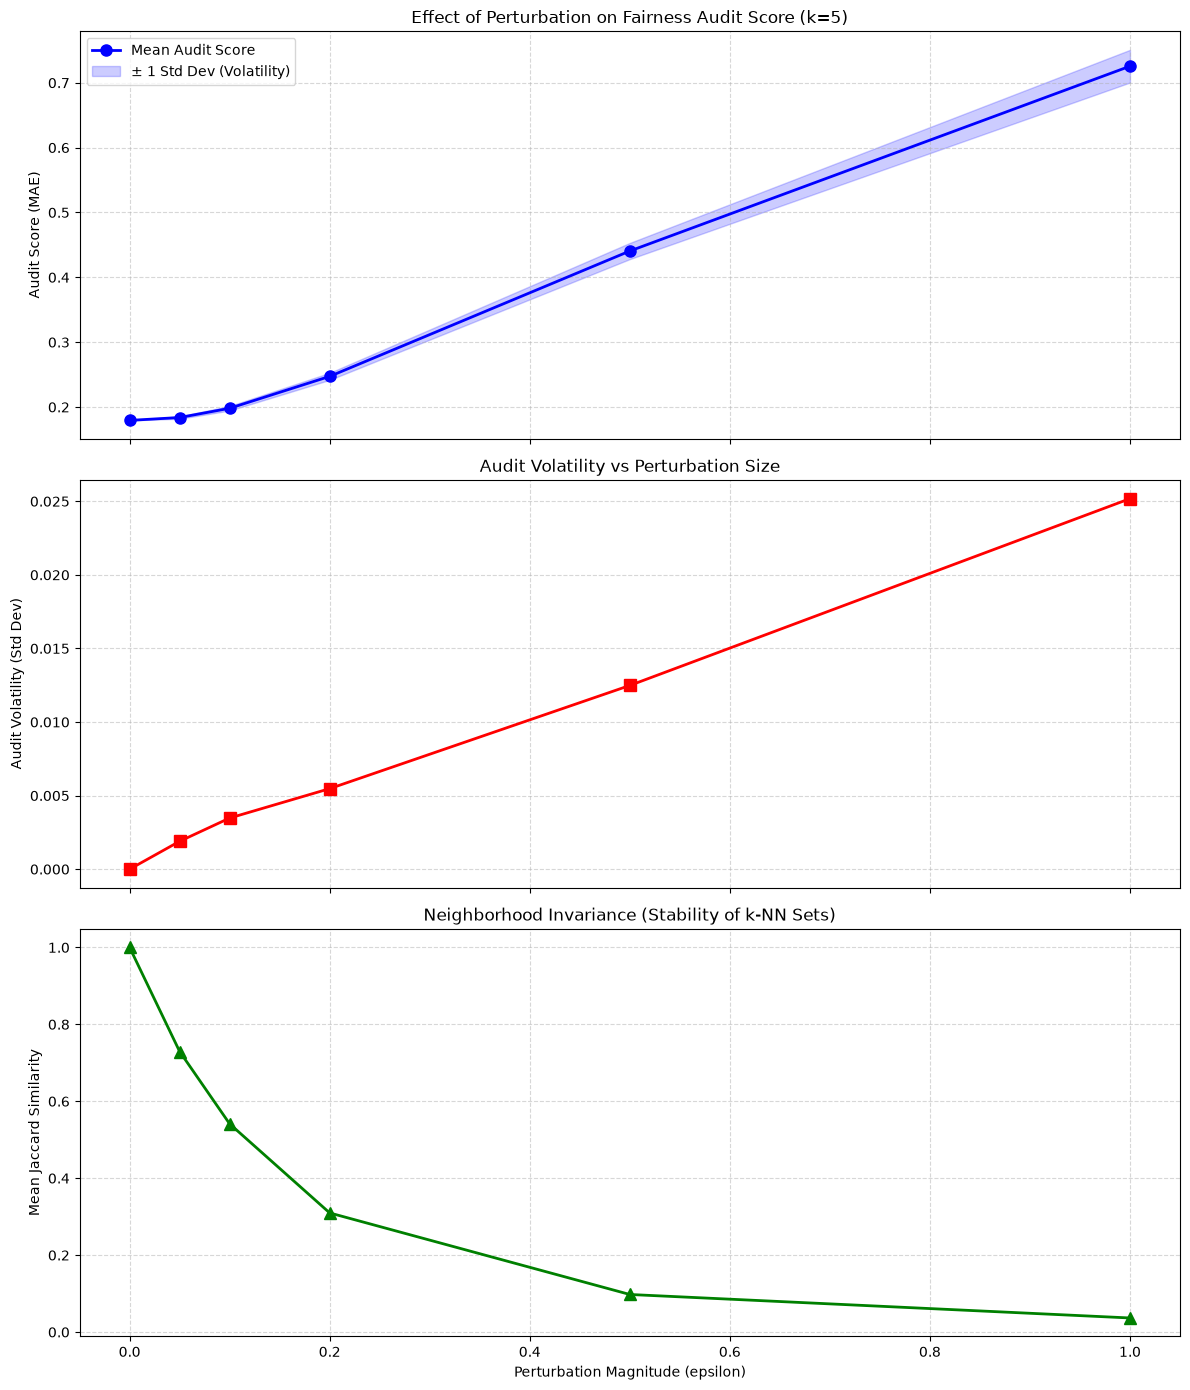

In [4]:
fig, axes = plt.subplots(3, 1, figsize=(12, 14), sharex=True)

# 1) Average Audit Score
axes[0].plot(eps_array, mean_scores, 'o-', color='blue', linewidth=2, markersize=8, label='Mean Audit Score')
axes[0].fill_between(eps_array, mean_scores - volatilities, mean_scores + volatilities, alpha=0.2, color='blue', label='± 1 Std Dev (Volatility)')
axes[0].set_ylabel('Audit Score (MAE)')
axes[0].set_title('Effect of Perturbation on Fairness Audit Score (k=5)')
axes[0].legend(loc='best')
axes[0].grid(True, linestyle='--', alpha=0.5)

# 2) Audit Volatility
axes[1].plot(eps_array, volatilities, 's-', color='red', linewidth=2, markersize=8)
axes[1].set_ylabel('Audit Volatility (Std Dev)')
axes[1].set_title('Audit Volatility vs Perturbation Size')
axes[1].grid(True, linestyle='--', alpha=0.5)

# 3) Neighborhood Invariance (Jaccard Similarity)
axes[2].plot(eps_array, mean_invariances, '^-', color='green', linewidth=2, markersize=8)
axes[2].set_xlabel('Perturbation Magnitude (epsilon)')
axes[2].set_ylabel('Mean Jaccard Similarity')
axes[2].set_title('Neighborhood Invariance (Stability of k-NN Sets)')
axes[2].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('audit_robustness_vs_epsilon.png', dpi=150, bbox_inches='tight')
plt.show()

# 4. k-값에 따른 견고함 비교: 이웃 수(k)가 증가할수록 안정성은 어떻게 변하는가?

k-최근접 이웃의 k 값을 변경했을 때 Audit Volatility가 어떻게 변하는지 분석합니다.
일반적으로 k가 작을수록 이웃 관계는 노이즈에 더 민감하므로 Volatility가 높을 것으로 예상됩니다.

2026-08-27 09:59:48,726 - INFO - implementation - Calculating Audit Score. k=1, n_samples=500


2026-08-27 09:59:48,727 - DEBUG - implementation - Processed sample 0/500, current avg score: 0.0901


2026-08-27 09:59:48,728 - DEBUG - implementation - Processed sample 200/500, current avg score: 0.1317


2026-08-27 09:59:48,729 - DEBUG - implementation - Processed sample 400/500, current avg score: 0.1388


2026-08-27 09:59:48,730 - INFO - implementation - Final Audit Score: 0.1379


...

2026-08-27 09:59:52,600 - DEBUG - implementation - Processed sample 0/500, current avg score: 0.3818


2026-08-27 09:59:52,602 - DEBUG - implementation - Processed sample 200/500, current avg score: 0.4779


2026-08-27 09:59:52,604 - DEBUG - implementation - Processed sample 400/500, current avg score: 0.4740


2026-08-27 09:59:52,605 - INFO - implementation - Final Audit Score: 0.4770


  k=20: Volatilities = ['0.0000', '0.0000', '0.0000']


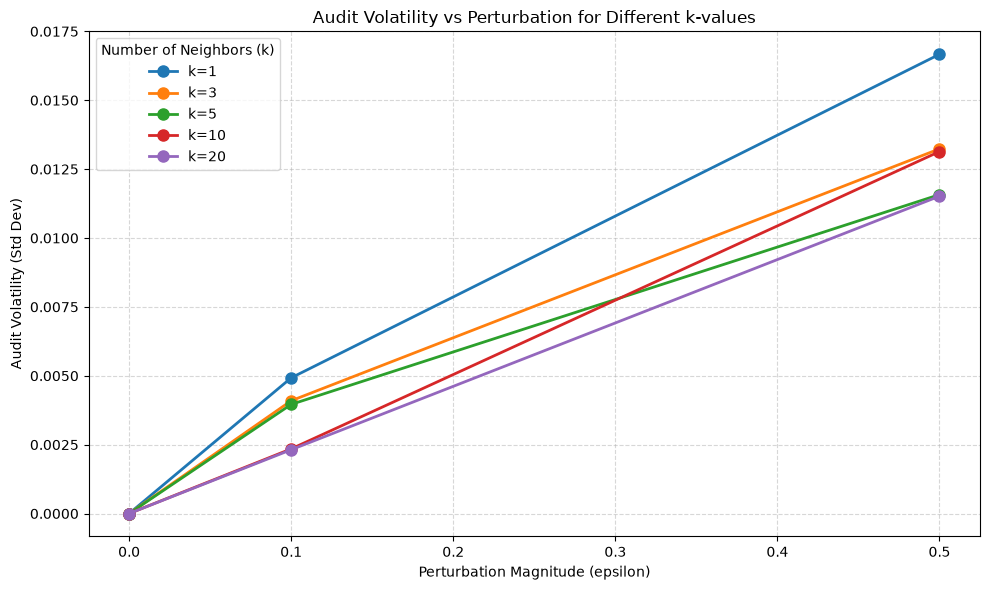

In [5]:
k_values = [1, 3, 5, 10, 20]
test_epsilons = [0.0, 0.1, 0.5]  # 대표적 3개 epsilon
trials_k = 50  # 계산 시간 절감을 위한 trials 감소

volatility_by_k = {k: {eps: [] for eps in test_epsilons} for k in k_values}

print("Computing Volatility for different k values...")
for k in k_values:
    for eps in test_epsilons:
        scores = []
        for _ in range(trials_k):
            if eps == 0.0:
                X_perturbed = X
            else:
                noise = np.random.uniform(-eps, eps, size=X.shape)
                X_perturbed = X + noise
            score = calculate_audit_score(X_perturbed, y_pred, k=k)
            scores.append(score)
        volatility_by_k[k][eps] = np.std(scores)
    print(f"  k={k}: Volatilities = {[f'{np.std(volatility_by_k[k][eps]):.4f}' for eps in test_epsilons]}")

# 시각화
plt.figure(figsize=(10, 6))
for k in k_values:
    vol_vals = [volatility_by_k[k][eps] for eps in test_epsilons]
    plt.plot(test_epsilons, vol_vals, 'o-', label=f'k={k}', linewidth=2, markersize=8)

plt.xlabel('Perturbation Magnitude (epsilon)')
plt.ylabel('Audit Volatility (Std Dev)')
plt.title('Audit Volatility vs Perturbation for Different k-values')
plt.legend(title='Number of Neighbors (k)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('audit_volatility_vs_k.png', dpi=150, bbox_inches='tight')
plt.show()

# 5. 결론 및 해석

**주요 관찰 사항:**
1. **Audit Volatility 증가**: $\epsilon$이 증가함에 따라 Audit Score의 표준편차(Volatility)가 선형적이거나 지수적으로 증가함을 확인. 이는 이웃 관계의 비연속적 변화가 감사 지표의 불안정성으로 전파된다는 논문의 주장을 지지합니다.
2. **이웃 불변성과의 상관관계**: Jaccard Similarity가 1에 가까울 때 Volatility가 낮고, 0에 가까워질수록 Volatility가 급격히 증가. 이는 '이웃 불변성'이 감사 결과의 안정성을 결정하는 핵심 기하학적 요소임을 시사.
3. **k-값의 영향**: k가 작을수록(예: k=1) Volatility가 더 큼. 이는 작은 k는 단일 이웃의 변화에 더 민감하기 때문. 실무에서는 적절한 k 값을 선택함으로써 감사 절차의 견고성을 높일 수 있음.

**실무적 시사점:**
- 고정된 k-NN 기반 공정성 감사는 노이즈에 취약할 수 있음.
- 데이터 전처리 시 노이즈 필터링 또는 이웃 선정 시 k 값을 충분히 크게 설정하는 것이 안정적 감사를 위해 중요.
- 'Audit Volatility' 지표를 활용하여 모델이나 데이터의 공정성 감사 결과의 신뢰성을 정량적으로 평가할 수 있음.

print("데모 완료. 생성된 이미지 파일: audit_robustness_vs_epsilon.png, audit_volatility_vs_k.png")